In [1]:
import json

from autorank import (
    autorank,
    create_report,
    latex_table,
)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

### Load the data

In [2]:
tasks_df = pd.read_csv("../assets/tasks.csv")
tasks_df = tasks_df.loc[tasks_df["Task type"].isin(["Binary classification", "Multi-class classification", "Multi-label classification", "Regression"])]

In [3]:
models_df = pd.read_csv("../assets/models_min.csv")

In [ ]:
results_paths = {
    "Open-source":  "./results/finetuning/{task_id}/{version}/{model_id}/test_results.json",    
    "Proprietary": "./results/prompting/{shots_strategy}/{task_id}/{model_id}/test_results.json",
    "Baseline": "./results/baselines/{model_id}/{task_id}/test_results.json"
}

In [5]:
metrics = {
    "Regression": "smape",
    "default": "f1_macro"
}

In [6]:
models_v4 = ["llama3.2-1b", "llama3.2-3b", "starcoder2-3b", "starcoder2-7b"]
tasks_v4 = ["functional_requirement", "incivility", "quality_requirement", "safety_issue", "security_requirement", "tone_bearing",
            "commit_intent", "issue_intention", "review_type",
            "comment_type_java", "comment_type_pharo", "comment_type_python", "review_aspect", "smell_doc"]

In [7]:
all_results = []


def load_results(path):
    with open(path, "r") as f:
        results = json.load(f)
        results = {k.replace("eval_", ""): v for k, v in results.items()}
    
    if task["Task type"] in metrics.keys():
        metric = metrics[task["Task type"]]
    else:
        metric = metrics["default"]

    row = task.to_dict() | model.to_dict()
    row["Score"] = results[metric]

    return row


for i, task in tasks_df.iterrows():
    print(f"\nINFO: Working on task={task["Task ID"]}\n---")
    for j, model in models_df.iterrows():
        if model["Model type"] == "Proprietary":
                path_ = results_paths[model["Model type"]].format(
                    shots_strategy=model["Shots strategy"],
                    task_id=task["Task ID"],
                    model_id=model["Model ID"]
                )
        elif model["Model type"] == "Open-source":
            if (model["Model ID"] in models_v4) and (task["Task ID"] in tasks_v4):
                version = "v4"
                print(f"INFO: Loading {version} for model={model["Model ID"]} task={task["Task ID"]}")
            else:
                version = "v3"
            path_ = results_paths[model["Model type"]].format(
                task_id=task["Task ID"],
                version=version,
                model_id=model["Model ID"]
            )
        else:
            path_ = results_paths[model["Model type"]].format(
                model_id=model["Model ID"],
                task_id=task["Task ID"]
            )

        try:
            row = load_results(path_)
            all_results.append(row)
        except FileNotFoundError:
            print(f"ERR: Results not found for for model={model["Model ID"]} task={task["Task ID"]}, path= {path_}")
            # print(f" - INFO: Temporally loading previous results")
            # path_ = path_.replace("v4", "v3")
            # row = load_results(path_)
            # all_results.append(row)

all_results_df = pd.DataFrame(all_results)

# Calculating the inverse value of sMAPE (1-sMAPE)
all_results_df["Score"] = all_results_df.apply(lambda x: (1 - x["Score"]) if x["Task type"] == "Regression" else x["Score"], axis=1)


INFO: Working on task=bug_issue
---

INFO: Working on task=functional_requirement
---
INFO: Loading v4 for model=llama3.2-1b task=functional_requirement
INFO: Loading v4 for model=llama3.2-3b task=functional_requirement
INFO: Loading v4 for model=starcoder2-3b task=functional_requirement
INFO: Loading v4 for model=starcoder2-7b task=functional_requirement

INFO: Working on task=incivility
---
INFO: Loading v4 for model=llama3.2-1b task=incivility
INFO: Loading v4 for model=llama3.2-3b task=incivility
INFO: Loading v4 for model=starcoder2-3b task=incivility
INFO: Loading v4 for model=starcoder2-7b task=incivility

INFO: Working on task=quality_requirement
---
INFO: Loading v4 for model=llama3.2-1b task=quality_requirement
INFO: Loading v4 for model=llama3.2-3b task=quality_requirement
INFO: Loading v4 for model=starcoder2-3b task=quality_requirement
INFO: Loading v4 for model=starcoder2-7b task=quality_requirement

INFO: Working on task=safety_issue
---
INFO: Loading v4 for model=llama

In [8]:
all_results_df.shape

(560, 14)

In [9]:
all_results_df.sample(10)

,Task type,Task ID,Activity,Family,Source,Model ID,Model name,Model architecture,Model size,Number of parameters,Domain adaptation,Model type,Shots strategy,Score
8,Binary classification,bug_issue,Quality assurance,Code-adjacent metadata,Issue tracking systems,gpt2-large,GPT-2 large,Decoder-only,Million params.,7.740301e+08,Generalist,Open-source,NaN,0.871385
86,Binary classification,quality_requirement,Requirements analysis,Core non-code,Requirements specifications,roberta-base,RoBERTa base,Encoder-only,Million params.,1.246456e+08,Generalist,Open-source,NaN,0.802062
320,Multi-class classification,question_quality,Software management,Developer communication,Developer forums,t5-small,T5 small,Encoder-decoder,Million params.,6.050662e+07,Generalist,Open-source,NaN,0.819098
451,Multi-label classification,comment_type_python,Software development,Code-adjacent metadata,Code repositories,roberta-large,RoBERTa large,Encoder-only,Million params.,3.553597e+08,Generalist,Open-source,NaN,0.105329
457,Multi-label classification,comment_type_python,Software development,Code-adjacent metadata,Code repositories,gpt2-xl,GPT-2 xl,Decoder-only,Billion params.,1.557611e+09,Generalist,Open-source,NaN,0.649340
88,Binary classification,quality_requirement,Requirements analysis,Core non-code,Requirements specifications,modernbert-base,ModernBERT base,Encoder-only,Million params.,1.490143e+08,Generalist,Open-source,NaN,0.834220
354,Multi-class classification,review_type,Software maintenance,Core non-code,App stores,starcoder2-3b,StarCoder2 3B,Decoder-only,Billion params.,3.030371e+09,Domain-adapted,Open-source,NaN,0.734680
117,Binary classification,safety_issue,Quality assurance,Code-adjacent metadata,Issue tracking systems,modernbert-large,ModernBERT large,Encoder-only,Million params.,3.947817e+08,Generalist,Open-source,NaN,0.850762
446,Multi-label classification,comment_type_pharo,Software development,Code-adjacent metadata,Code repositories,sklearn,TF-IDF+XGBoost,NaN,NaN,NaN,NaN,Baseline,NaN,0.497991
12,Binary classification,bug_issue,Quality assurance,Code-adjacent metadata,Issue tracking systems,t5-small,T5 small,Encoder-decoder,Million params.,6.050662e+07,Generalist,Open-source,NaN,0.831826


### Run Autorank

In [10]:
all_results_pivot_df = all_results_df.pivot(index="Task ID", columns="Model name", values="Score")
all_results_pivot_df = all_results_pivot_df.reset_index(drop=True)

In [11]:
all_results_pivot_df.sample(5)

Model name,BERT base,BERT large,Claude 3.7 (3-shot),Claude 3.7 (zero-shot),CodeBERT base,CodeLlama 7B,CodeT5+ 220M,CodeT5+ 770M,FastText,GPT-2 large,...,ModernBERT large,RoBERTa base,RoBERTa large,StarCoder2 3B,StarCoder2 7B,T5 3B,T5 base,T5 large,T5 small,TF-IDF+XGBoost
14,0.854068,0.859880,0.776606,0.694084,0.848696,0.838261,0.783841,0.846561,0.774347,0.840102,...,0.850762,0.850458,0.845179,0.862486,0.863752,0.830459,0.838293,0.855278,0.850015,0.787775
9,0.781760,0.786271,0.740434,0.728538,0.791197,0.814244,0.762954,0.772580,0.722530,0.794365,...,0.802629,0.791760,0.798105,0.807932,0.807438,0.800276,0.773783,0.785615,0.741974,0.713748
10,0.834220,0.854103,0.817664,0.812829,0.811189,0.399643,0.821346,0.787140,0.722263,0.843682,...,0.827747,0.802062,0.839840,0.815054,0.796605,0.845911,0.796206,0.863859,0.773827,0.779720
2,0.767538,0.788772,0.465536,0.429480,0.717856,0.822698,0.824027,0.806507,0.658527,0.795472,...,0.812255,0.772129,0.643129,0.803998,0.792058,0.662195,0.770005,0.787095,0.594140,0.682372
8,0.843428,0.850026,0.705450,0.645364,0.855557,0.845062,0.815049,0.834330,0.687311,0.873337,...,0.861272,0.865773,0.854634,0.870651,0.881654,0.879055,0.847362,0.859328,0.859095,0.736287


In [12]:
result = autorank(all_results_pivot_df, alpha=0.05, approach="bayesian", verbose=False)

In [13]:
result.rankdf

,mean,std,ci_lower,ci_upper,effect_size,magnitude,p_equal,p_smaller,decision
Model name,,,,,,,,,
GPT-2 xl,0.754600,0.130435,0.605886,0.903315,0.0,negligible,NaN,NaN,NA
Llama 3.2 3B,0.746648,0.128191,0.600491,0.892804,0.061498,negligible,0.69302,0.27912,inconclusive
GPT-2 large,0.746367,0.140629,0.58603,0.906705,0.060703,negligible,0.92790,0.06394,inconclusive
GPT-2 medium,0.739725,0.140633,0.579382,0.900068,0.109677,negligible,0.67316,0.32658,inconclusive
Llama 3.2 1B,0.739074,0.127657,0.593527,0.884622,0.120308,negligible,0.62442,0.37558,inconclusive
GPT-2 small,0.733786,0.133996,0.581011,0.886562,0.15741,negligible,0.57126,0.42818,inconclusive
StarCoder2 3B,0.733764,0.155564,0.556399,0.91113,0.14515,negligible,0.51012,0.40994,inconclusive
T5 large,0.732636,0.154078,0.556964,0.908308,0.15387,negligible,0.46660,0.53330,inconclusive
CodeT5+ 770M,0.730978,0.138738,0.572795,0.88916,0.175437,negligible,0.03222,0.93296,inconclusive


In [14]:
create_report(result)

The statistical analysis was conducted for 28 populations with 20 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We failed to reject the null hypothesis that the population is normal for all populations (minimal observed p-value=0.002). Therefore, we assume that all populations are normal.
We used a bayesian signed rank test to determine differences between the mean values of the populations and report the mean value (M) and the standard deviation (SD) for each population. We distinguish between populations being pair-wise smaller, equal, or larger and make a decision for one of these cases if we estimate that the posterior probability is at least alpha=0.050.
We used the effect size to define the region of practical equivalence (ROPE) around the mean value dynamically as 0.100*d.
We found significant and practically relevant differences between the populations GPT-2 xl (M=0.755+-0.149, SD=0.130), Llama 3.2 3B (M=0.747+-0.146, SD=0.128), GPT-2 large (M=

In [15]:
# latex_table(result)

### Plot model ranking

In [16]:
df = result.rankdf[["mean", "ci_lower", "ci_upper"]]
df.loc[:,"ci_lower"] = df["mean"] - df["ci_lower"]
df.loc[:,"ci_upper"] = df["ci_upper"] - df["mean"]

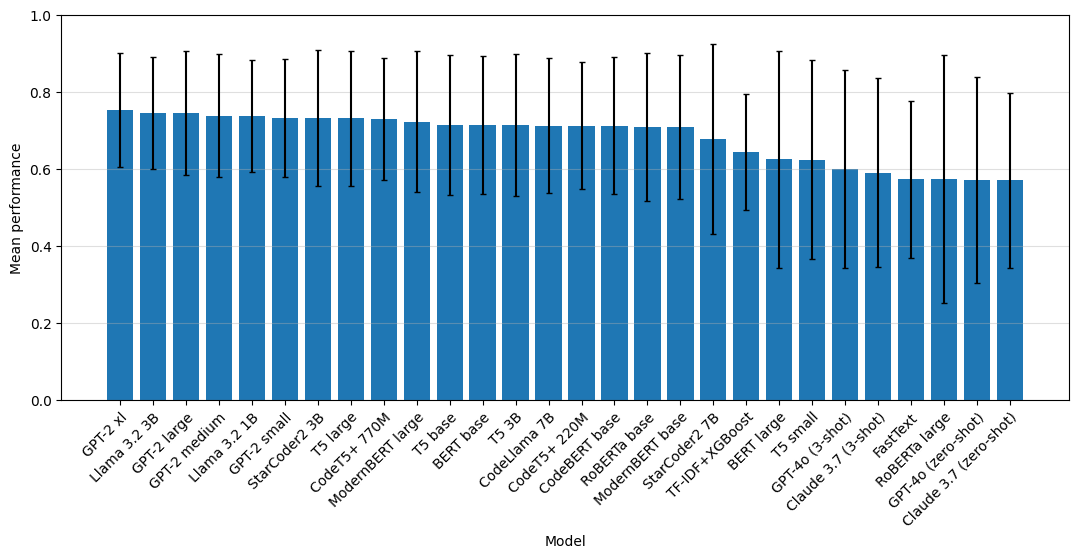

In [17]:
plt.figure(figsize=(13, 5))
plt.bar(
    df.index,
    df["mean"],
    yerr=df[["ci_lower", "ci_upper"]].T,
    capsize=2,
    align="center"
)
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.grid(axis="y", alpha=.4)
plt.ylabel("Mean performance")
plt.xlabel("Model")
plt.ylim([0, 1])
plt.show()

### Plot posterior matrices

In [18]:
posterior_matrix_smaller_df = pd.DataFrame(np.nan, index=result.posterior_matrix.index, columns=result.posterior_matrix.columns)
posterior_matrix_equal_df = pd.DataFrame(np.nan, index=result.posterior_matrix.index, columns=result.posterior_matrix.columns)
posterior_matrix_larger_df = pd.DataFrame(np.nan, index=result.posterior_matrix.index, columns=result.posterior_matrix.columns)
posterior_matrix_inconclusive_df = pd.DataFrame(np.nan, index=result.posterior_matrix.index, columns=result.posterior_matrix.columns)
posterior_matrix_decision_df = pd.DataFrame(np.nan, index=result.posterior_matrix.index, columns=result.posterior_matrix.columns)

for i in range(result.posterior_matrix.shape[0]):
    for j in range(result.posterior_matrix.shape[1]):
        if isinstance(result.posterior_matrix.iloc[i, j], tuple):
            p_smaller, p_equal, p_larger = result.posterior_matrix.iloc[i, j]
            posterior_matrix_smaller_df.iloc[i, j] = p_smaller
            posterior_matrix_equal_df.iloc[i, j] = p_equal
            posterior_matrix_larger_df.iloc[i, j] = p_larger
            posterior_matrix_inconclusive_df.iloc[i, j] = ((p_smaller < 0.95) & (p_equal < 0.95) & (p_larger < 0.95)).astype(int)

            decision = 0
            if p_smaller >= 0.95:
                decision = 3
            elif p_equal >= 0.95:
                decision = 2
            elif p_larger >= 0.95:
                decision = 1
            posterior_matrix_decision_df.iloc[i, j] = decision

/tmp/ipykernel_3387370/2463217940.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


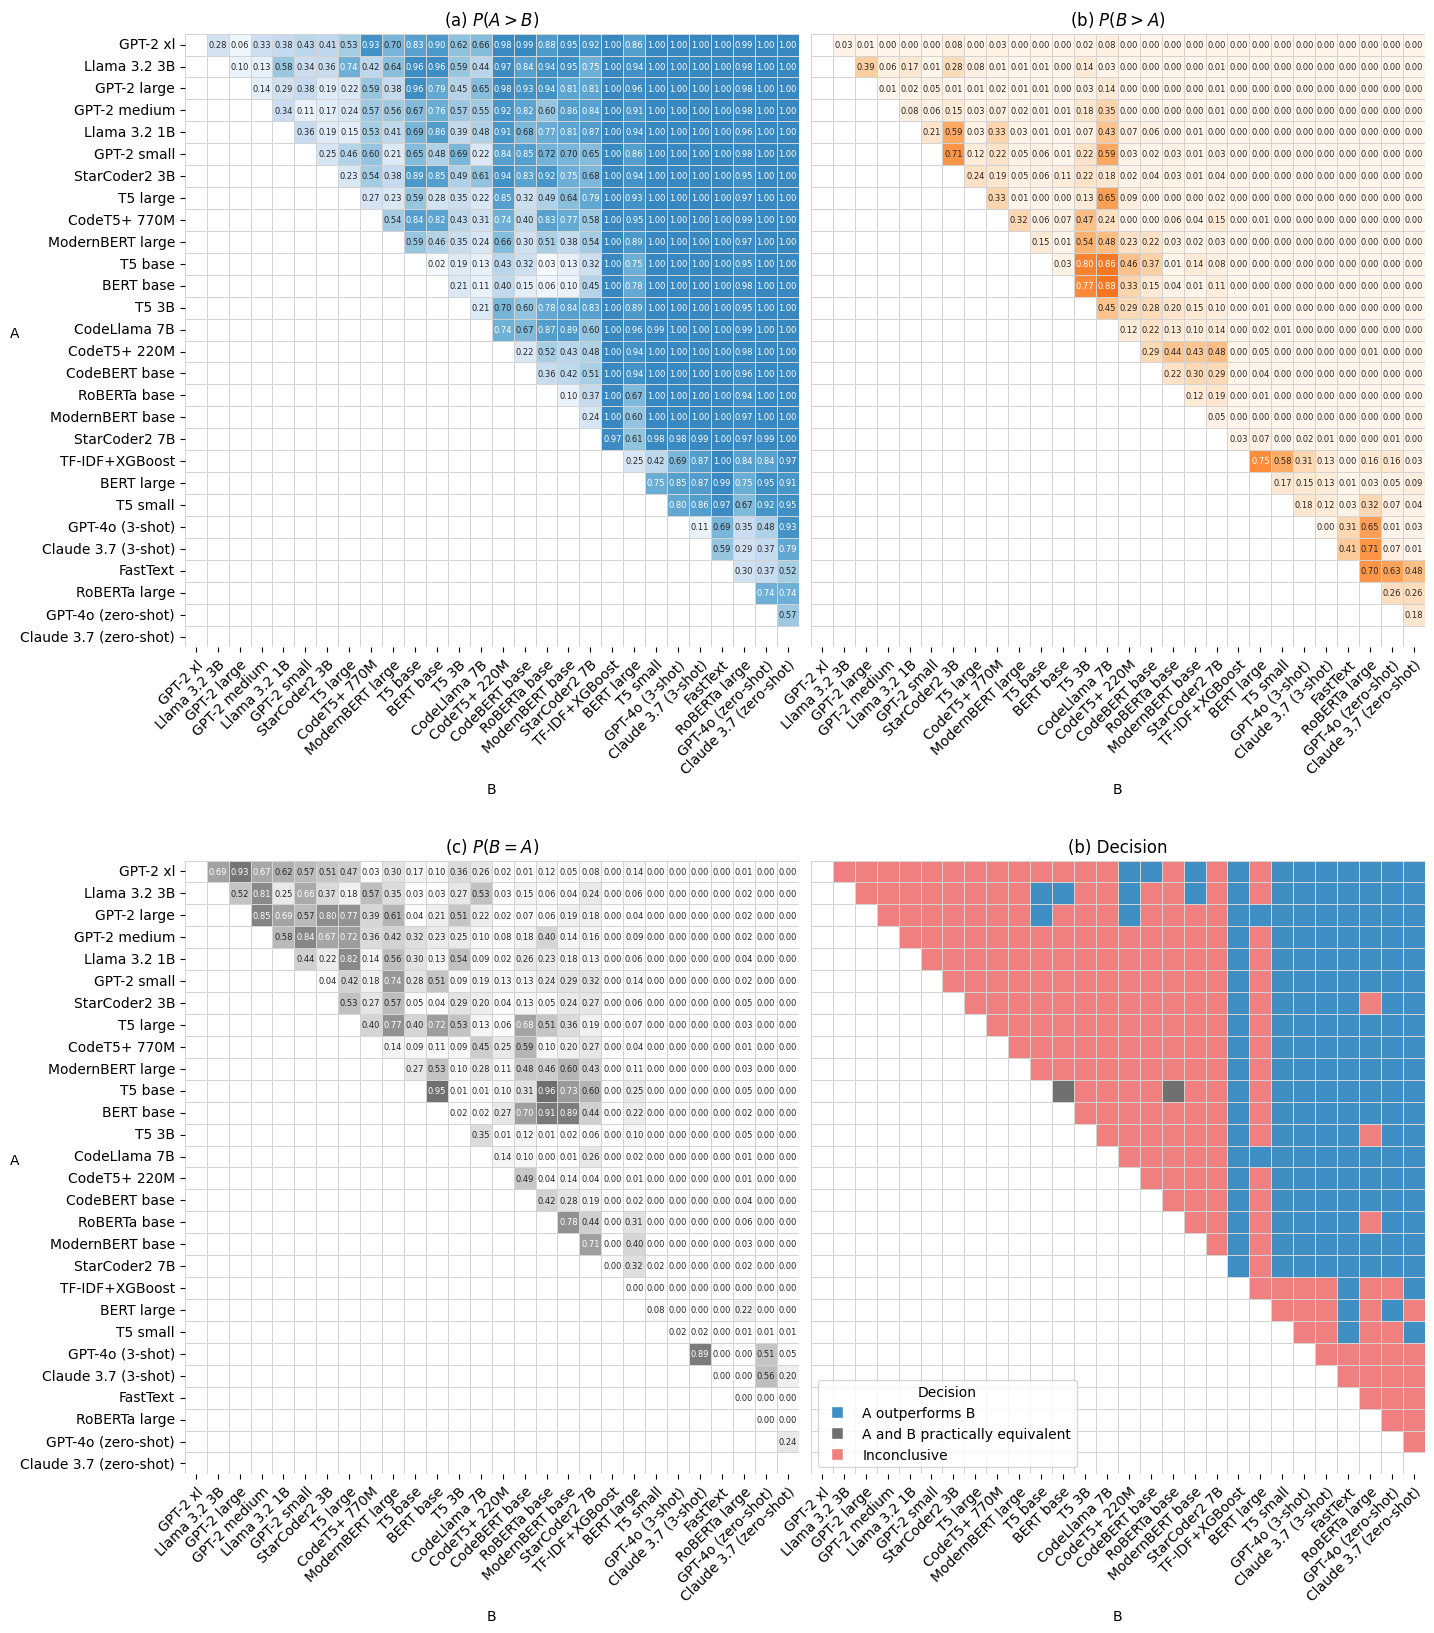

In [19]:
fig = plt.figure(figsize=(16, 19))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], wspace=0.02, hspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

sns.heatmap(
    posterior_matrix_smaller_df,
    vmin=0, vmax=1.5,
    cmap="Blues",
    annot=True, fmt=".2f", annot_kws={"fontsize": 6},
    linewidths=0.5, linecolor="lightgray",
    square=True, cbar=False,
    ax=ax1
)
ax1.set_title("(a) $P(A > B)$")
ax1.set_xlabel("B")

ax1.set_ylabel("A", rotation=0)

sns.heatmap(
    posterior_matrix_larger_df,
    vmin=0, vmax=1.5,
    cmap="Oranges",
    annot=True, fmt=".2f", annot_kws={"fontsize": 6},
    linewidths=0.5, linecolor="lightgray",
    square=True, cbar=False,
    ax=ax2
)
ax2.set_title("(b) $P(B > A)$")
ax2.set_xlabel("B")

# ax2.set_ylabel("A", rotation=0)
plt.setp(ax2.get_yticklabels(), visible=False)
# ax2.yaxis.tick_right()   # if you want ticks on the right but no labels, you can use this
ax2.yaxis.set_ticks_position("none")  # remove tick marks entirely
ax2.set_ylabel("")  # remove the “A” label

sns.heatmap(
    posterior_matrix_equal_df,
    vmin=0, vmax=1.5,
    cmap="Greys",
    annot=True, fmt=".2f", annot_kws={"fontsize": 6},
    linewidths=0.5, linecolor="lightgray",
    square=True, cbar=False,
    ax=ax3
)
ax3.set_title("(c) $P(B = A)$")
ax3.set_xlabel("B")
ax3.set_ylabel("A", rotation=0)

cmap = ListedColormap([
    "lightcoral",  # 0: inconclusive
    "#ef6612",  # 1: B > A
    "#707070",  # 2: tie
    "#3f8fc5",  # 3: A > B
])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = BoundaryNorm(bounds, cmap.N)

sns.heatmap(
    posterior_matrix_decision_df,
    #vmin=0, vmax=1,
    cmap=cmap, norm=norm,
    linewidths=0.5, linecolor="lightgray",
    square=True, cbar=False,
    ax=ax4
)
ax4.set_title("(b) Decision")
ax4.set_xlabel("B")

# ax4.set_ylabel("A", rotation=0)
plt.setp(ax4.get_yticklabels(), visible=False)
# ax4.yaxis.tick_right()   # if you want ticks on the right but no labels, you can use this
ax4.yaxis.set_ticks_position("none")  # remove tick marks entirely
ax4.set_ylabel("")  # remove the "A" label

legend_handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#3f8fc5",  markersize=9, label="A outperforms B"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#707070",  markersize=9, label="A and B practically equivalent"),
    # Line2D([0], [0], marker="s", color="w", markerfacecolor="#ef6612",  markersize=9, label="B outperforms A"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="lightcoral",  markersize=9, label="Inconclusive"),
]
ax4.legend(title="Decision", handles=legend_handles, loc="lower left")

plt.sca(ax1)
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.sca(ax2)
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.sca(ax3)
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.sca(ax4)
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")

plt.tight_layout()

plt.savefig("posterior_matrices.pdf", format="pdf", bbox_inches="tight")

plt.show()